# NetFlow Predictor Lab Notebook



In [3]:
import html
from textwrap import dedent

import pandas as pd
from IPython.display import Markdown, SVG, display


def make_bar_svg(df, label_col, value_col, title, positive_good=False, width=900, row_height=28):
    if df.empty:
        return SVG('<svg xmlns="http://www.w3.org/2000/svg" width="800" height="40"><text x="10" y="25">no data</text></svg>')

    values = df[value_col].tolist()
    labels = df[label_col].tolist()
    max_abs = max(abs(value) for value in values) or 1.0
    left_margin = 320
    right_margin = 140
    top_margin = 45
    center_x = left_margin + (width - left_margin - right_margin) / 2
    chart_half_width = (width - left_margin - right_margin) / 2
    height = top_margin + len(df) * row_height + 30
    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}">',
        '<style>text { font-family: Menlo, monospace; font-size: 12px; } .title { font-size: 16px; font-weight: bold; }</style>',
        f'<text class="title" x="12" y="24">{html.escape(title)}</text>',
        f'<line x1="{center_x:.1f}" y1="35" x2="{center_x:.1f}" y2="{height - 15}" stroke="#777" stroke-width="1" />'
    ]

    for index, (label, value) in enumerate(zip(labels, values)):
        y = top_margin + index * row_height
        bar_width = chart_half_width * abs(value) / max_abs
        x = center_x if value >= 0 else center_x - bar_width
        fill = '#1f77b4'
        if positive_good:
            fill = '#2ca02c' if value >= 0 else '#d62728'
        else:
            fill = '#2ca02c' if value <= 0 else '#d62728'
        parts.append(f'<text x="12" y="{y + 14}">{html.escape(str(label))}</text>')
        parts.append(
            f'<rect x="{x:.1f}" y="{y}" width="{bar_width:.1f}" height="18" fill="{fill}" opacity="0.85" rx="2" />'
        )
        value_x = center_x + chart_half_width + 12
        parts.append(f'<text x="{value_x:.1f}" y="{y + 14}">{value:+.4f}</text>')

    parts.append('</svg>')
    return SVG(''.join(parts))


def show_command(command):
    display(Markdown(f'```bash\n{command}\n```'))


## 1. Project Framing

Current question:
- do Spectrum / Structure add predictive value for next-window unique IP behavior?

Working lesson so far:
- exact next-count is very persistence-dominated
- delta prediction is a better lens for MAAD signal
- Structure is the most promising MAAD family so far


### Quick glossary

- `sa` = source address
- `da` = destination address
- `ipv4` = IPv4 address family
- `next_sa_ipv4_count` = next window's unique IPv4 source-address count
- `next_sa_ipv4_count_delta` = next window count minus current window count
- `target` block = lags and rolling stats for the count family being predicted
- `general` block = traffic totals, protocol counts, clock features, router identity
- `structure_summary` = compact summary stats from the Structure curve
- `structure_tau_samples` = sampled points from the Structure `tau` curve
- `structure_sd_samples` = sampled points from the Structure `sd` curve
- `MAE` = mean absolute error; lower is better
- `R2` = fraction of variance explained; higher is better
- `persistence baseline` = the trivial predictor used as the reference point
  - for exact count: predict next count from current count
  - for delta: predict `0`


In [4]:
results_rows = [
    {
        'target': 'next_sa_ipv4_count',
        'blocks': 'target',
        'persist_val_mae': 590.57,
        'model_val_mae': 590.57,
        'persist_test_mae': 549.71,
        'model_test_mae': 660.46,
        'persist_val_r2': 0.996892,
        'model_val_r2': 0.996892,
        'persist_test_r2': 0.998814,
        'model_test_r2': 0.998698,
        'family': 'exact_count',
    },
    {
        'target': 'next_sa_ipv4_count',
        'blocks': 'target,general,spectrum',
        'persist_val_mae': 590.57,
        'model_val_mae': 590.57,
        'persist_test_mae': 549.71,
        'model_test_mae': 738.77,
        'persist_val_r2': 0.996892,
        'model_val_r2': 0.996892,
        'persist_test_r2': 0.998814,
        'model_test_r2': 0.998590,
        'family': 'exact_count',
    },
    {
        'target': 'next_da_ipv4_count',
        'blocks': 'target,general',
        'persist_val_mae': 1592.59,
        'model_val_mae': 1592.59,
        'persist_test_mae': 1592.59,
        'model_test_mae': 2048.31,
        'persist_val_r2': 0.993943,
        'model_val_r2': 0.993943,
        'persist_test_r2': 0.993943,
        'model_test_r2': 0.994558,
        'family': 'exact_count',
    },
    {
        'target': 'next_sa_ipv4_count_delta',
        'blocks': 'target,general',
        'persist_val_mae': 590.57,
        'model_val_mae': 623.92,
        'persist_test_mae': 549.71,
        'model_test_mae': 555.75,
        'persist_val_r2': 0.0,
        'model_val_r2': -0.107698,
        'persist_test_r2': 0.0,
        'model_test_r2': 0.099487,
        'family': 'delta',
    },
    {
        'target': 'next_sa_ipv4_count_delta',
        'blocks': 'target,general,structure',
        'persist_val_mae': 590.57,
        'model_val_mae': 582.60,
        'persist_test_mae': 549.71,
        'model_test_mae': 524.59,
        'persist_val_r2': 0.0,
        'model_val_r2': -0.007254,
        'persist_test_r2': 0.0,
        'model_test_r2': 0.165848,
        'family': 'delta',
    },
    {
        'target': 'next_sa_ipv4_count_delta',
        'blocks': 'target,general,structure_summary,structure_sd_samples',
        'persist_val_mae': 590.57,
        'model_val_mae': 588.33,
        'persist_test_mae': 549.71,
        'model_test_mae': 526.16,
        'persist_val_r2': 0.0,
        'model_val_r2': -0.009993,
        'persist_test_r2': 0.0,
        'model_test_r2': 0.163544,
        'family': 'delta',
    },
    {
        'target': 'next_sa_ipv4_count_delta',
        'blocks': 'target,general,structure_tau_samples',
        'persist_val_mae': 590.57,
        'model_val_mae': 596.96,
        'persist_test_mae': 549.71,
        'model_test_mae': 537.69,
        'persist_val_r2': 0.0,
        'model_val_r2': -0.020925,
        'persist_test_r2': 0.0,
        'model_test_r2': 0.128867,
        'family': 'delta',
    },
    {
        'target': 'next_da_ipv4_count_delta',
        'blocks': 'target,general,spectrum',
        'persist_val_mae': 1592.59,
        'model_val_mae': 1592.59,
        'persist_test_mae': 1592.59,
        'model_test_mae': 1966.33,
        'persist_val_r2': 0.0,
        'model_val_r2': 0.0,
        'persist_test_r2': 0.0,
        'model_test_r2': 0.118000,
        'family': 'delta',
    },
]

results = pd.DataFrame(results_rows)
results['val_mae_delta'] = results['model_val_mae'] - results['persist_val_mae']
results['test_mae_delta'] = results['model_test_mae'] - results['persist_test_mae']
results['val_r2_delta'] = results['model_val_r2'] - results['persist_val_r2']
results['test_r2_delta'] = results['model_test_r2'] - results['persist_test_r2']
results[['target', 'blocks', 'val_mae_delta', 'test_mae_delta', 'val_r2_delta', 'test_r2_delta']]


,target,blocks,val_mae_delta,test_mae_delta,val_r2_delta,test_r2_delta
0,next_sa_ipv4_count,target,0.00,110.75,0.000000,-0.000116
1,next_sa_ipv4_count,"target,general,spectrum",0.00,189.06,0.000000,-0.000224
2,next_da_ipv4_count,"target,general",0.00,455.72,0.000000,0.000615
3,next_sa_ipv4_count_delta,"target,general",33.35,6.04,-0.107698,0.099487
4,next_sa_ipv4_count_delta,"target,general,structure",-7.97,-25.12,-0.007254,0.165848
5,next_sa_ipv4_count_delta,"target,general,structure_summary,structure_sd_...",-2.24,-23.55,-0.009993,0.163544
6,next_sa_ipv4_count_delta,"target,general,structure_tau_samples",6.39,-12.02,-0.020925,0.128867
7,next_da_ipv4_count_delta,"target,general,spectrum",0.00,373.74,0.000000,0.118000


## 2. Compare Exact-Count vs Delta

Two quick reads:
- for `MAE`, negative is good because the learned model beats persistence
- for `R2`, positive is good because the learned model improves on persistence

Short labels in the plots:
- `blocks` = which feature sets were enabled for that run
- `test_mae_delta` = learned-model test MAE minus persistence test MAE
- `test_r2_delta` = learned-model test R2 minus persistence test R2


In [5]:
exact_view = (
    results[results['family'] == 'exact_count']
    [['target', 'blocks', 'test_mae_delta', 'test_r2_delta']]
    .sort_values('test_mae_delta')
    .reset_index(drop=True)
)
delta_view = (
    results[results['family'] == 'delta']
    [['target', 'blocks', 'test_mae_delta', 'test_r2_delta']]
    .sort_values('test_mae_delta')
    .reset_index(drop=True)
)

display(Markdown('### Exact-count view'))
display(exact_view)
display(Markdown('### Delta view'))
display(delta_view)


### Exact-count view

,target,blocks,test_mae_delta,test_r2_delta
0,next_sa_ipv4_count,target,110.75,-0.000116
1,next_sa_ipv4_count,"target,general,spectrum",189.06,-0.000224
2,next_da_ipv4_count,"target,general",455.72,0.000615


### Delta view

,target,blocks,test_mae_delta,test_r2_delta
0,next_sa_ipv4_count_delta,"target,general,structure",-25.12,0.165848
1,next_sa_ipv4_count_delta,"target,general,structure_summary,structure_sd_...",-23.55,0.163544
2,next_sa_ipv4_count_delta,"target,general,structure_tau_samples",-12.02,0.128867
3,next_sa_ipv4_count_delta,"target,general",6.04,0.099487
4,next_da_ipv4_count_delta,"target,general,spectrum",373.74,0.118000


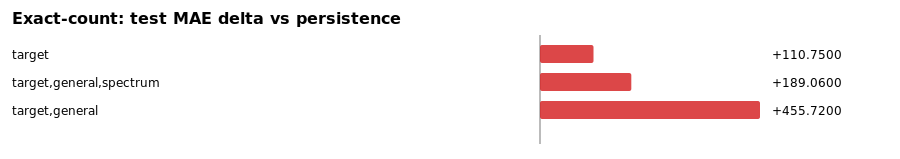

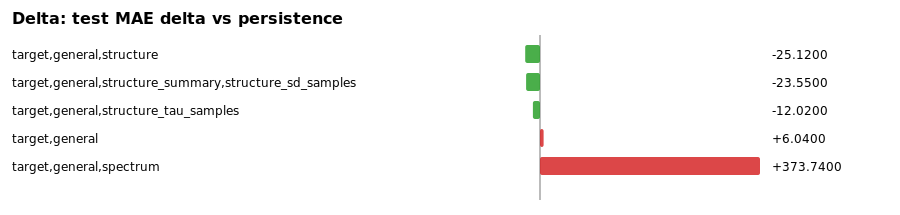

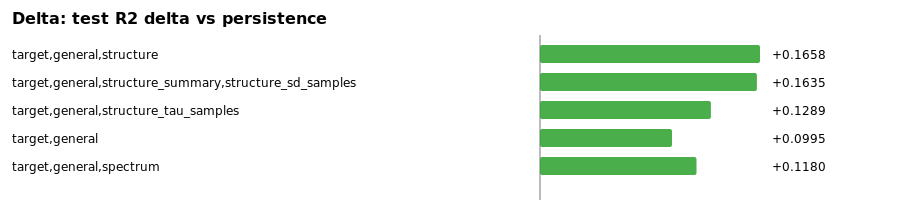

In [6]:
display(make_bar_svg(exact_view, 'blocks', 'test_mae_delta', 'Exact-count: test MAE delta vs persistence', positive_good=False))
display(make_bar_svg(delta_view, 'blocks', 'test_mae_delta', 'Delta: test MAE delta vs persistence', positive_good=False))
display(make_bar_svg(delta_view, 'blocks', 'test_r2_delta', 'Delta: test R2 delta vs persistence', positive_good=True))


## 3. Structure-Focused Ablation

These are the focused `next_sa_ipv4_count_delta` results from the structure sub-block experiments.

Reminder:
- `structure` = `structure_summary + structure_tau_samples + structure_sd_samples`
- this is the most promising thread found so far

Structure terms:
- `tau` = the main Structure curve values across sampled `q` settings
- `sd` = the spread / variability values stored alongside `tau`
- `summary` = min / max / mean / std style reductions over the curve
- `samples` = a small fixed set of points taken from left to right across the curve


In [ ]:
structure_rows = [
    {
        'blocks': 'target,general',
        'model_val_mae': 623.92,
        'model_test_mae': 555.75,
        'model_val_r2': -0.107698,
        'model_test_r2': 0.099487,
    },
    {
        'blocks': 'target,general,structure_summary',
        'model_val_mae': 598.69,
        'model_test_mae': 540.31,
        'model_val_r2': -0.013672,
        'model_test_r2': 0.135270,
    },
    {
        'blocks': 'target,general,structure_tau_samples',
        'model_val_mae': 596.96,
        'model_test_mae': 537.69,
        'model_val_r2': -0.020925,
        'model_test_r2': 0.128867,
    },
    {
        'blocks': 'target,general,structure_sd_samples',
        'model_val_mae': 609.58,
        'model_test_mae': 545.69,
        'model_val_r2': -0.097126,
        'model_test_r2': 0.112071,
    },
    {
        'blocks': 'target,general,structure_summary,structure_tau_samples',
        'model_val_mae': 587.77,
        'model_test_mae': 530.68,
        'model_val_r2': -0.007110,
        'model_test_r2': 0.141590,
    },
    {
        'blocks': 'target,general,structure_summary,structure_sd_samples',
        'model_val_mae': 588.33,
        'model_test_mae': 526.16,
        'model_val_r2': -0.009993,
        'model_test_r2': 0.163544,
    },
    {
        'blocks': 'target,general,structure',
        'model_val_mae': 582.60,
        'model_test_mae': 524.59,
        'model_val_r2': -0.007254,
        'model_test_r2': 0.165848,
    },
]

structure_df = pd.DataFrame(structure_rows)
structure_df['persist_val_mae'] = 590.57
structure_df['persist_test_mae'] = 549.71
structure_df['persist_val_r2'] = 0.0
structure_df['persist_test_r2'] = 0.0
structure_df['val_mae_delta'] = structure_df['model_val_mae'] - structure_df['persist_val_mae']
structure_df['test_mae_delta'] = structure_df['model_test_mae'] - structure_df['persist_test_mae']
structure_df['val_r2_delta'] = structure_df['model_val_r2'] - structure_df['persist_val_r2']
structure_df['test_r2_delta'] = structure_df['model_test_r2'] - structure_df['persist_test_r2']
structure_df.sort_values('test_mae_delta')


In [ ]:
display(make_bar_svg(structure_df.sort_values('test_mae_delta'), 'blocks', 'test_mae_delta', 'Structure ablation: test MAE delta vs persistence', positive_good=False, width=1100))
display(make_bar_svg(structure_df.sort_values('test_r2_delta', ascending=False), 'blocks', 'test_r2_delta', 'Structure ablation: test R2 delta vs persistence', positive_good=True, width=1100))
display(make_bar_svg(structure_df.sort_values('val_mae_delta'), 'blocks', 'val_mae_delta', 'Structure ablation: validation MAE delta vs persistence', positive_good=False, width=1100))


## 4. Ranked Structure Features

These weights come from the linear model trained on:
- target: `next_sa_ipv4_count_delta`
- blocks: `target,general,structure`
- epochs: `200`

They are standardized linear coefficients, so larger absolute values mean stronger influence inside this particular model.

How to read feature names:
- `structure_tau_sample_4` = the rightmost sampled `tau` point in the reduced Structure curve
- `structure_sd_mean` = mean of the Structure `sd` values
- `structure_tau_max` = largest `tau` value observed in the curve
- `coefficient` sign tells direction inside this linear model
- `abs_coefficient` is what we use for crude ranking strength


In [ ]:
ranking_rows = [
    ('structure_tau_sample_4', 0.879342, 'structure_tau_samples'),
    ('structure_sd_mean', 0.695006, 'structure_summary'),
    ('structure_sd_sample_3', 0.647577, 'structure_sd_samples'),
    ('structure_sd_std', -0.533628, 'structure_summary'),
    ('structure_sd_sample_4', -0.433997, 'structure_sd_samples'),
    ('structure_tau_max', -0.410644, 'structure_summary'),
    ('structure_tau_sample_3', -0.409847, 'structure_tau_samples'),
    ('structure_tau_sample_1', -0.176833, 'structure_tau_samples'),
    ('structure_tau_std', 0.175182, 'structure_summary'),
    ('structure_tau_mean', 0.150282, 'structure_summary'),
    ('structure_sd_sample_1', -0.104520, 'structure_sd_samples'),
    ('structure_points', 0.098643, 'structure_summary'),
    ('structure_sd_sample_0', 0.088807, 'structure_sd_samples'),
    ('structure_tau_sample_0', 0.080282, 'structure_tau_samples'),
    ('structure_tau_min', -0.048567, 'structure_summary'),
]

ranking_df = pd.DataFrame(ranking_rows, columns=['feature', 'coefficient', 'group'])
ranking_df['abs_coefficient'] = ranking_df['coefficient'].abs()
ranking_df = ranking_df.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)
ranking_df


In [ ]:
display(make_bar_svg(ranking_df, 'feature', 'coefficient', 'Ranked Structure coefficients', positive_good=True, width=1000, row_height=24))
ranking_df.groupby('group')['abs_coefficient'].sum().sort_values(ascending=False)


## 5. Commands to Rerun the Important Paths

Use these directly from the notebook, or copy them into a terminal.

Command notes:
- `--target` chooses the prediction task
- `--feature-blocks` chooses which feature families are loaded
- `--run-experiments` runs a small matrix instead of one config
- `--device cpu` keeps runs deterministic and avoids the current MPS instability on some exact-count paths


In [ ]:
commands = {
    'focused_structure_matrix': dedent('''
        uv run python main.py \
          --run-experiments \
          --epochs 200 \
          --experiment-targets 'next_sa_ipv4_count_delta' \
          --device cpu
    ''').strip(),
    'full_structure_block': dedent('''
        uv run python main.py \
          --epochs 200 \
          --target next_sa_ipv4_count_delta \
          --feature-blocks target,general,structure \
          --device cpu
    ''').strip(),
    'rank_structure_features': dedent('''
        uv run python main.py \
          --epochs 200 \
          --target next_sa_ipv4_count_delta \
          --feature-blocks target,general,structure \
          --device cpu \
          --show-feature-ranking \
          --ranking-prefixes structure_ \
          --ranking-top-k 15
    ''').strip(),
}

for name, command in commands.items():
    display(Markdown(f'### {name}'))
    show_command(command)


## 6. Working Interpretation

Where we are now:
- exact-count prediction is still mostly a persistence game
- delta prediction exposes useful signal
- Structure is the most promising MAAD family so far
- the full `structure` block and the best sub-block combos are very close
- the weight ranking suggests the strongest signal is not uniform across the curve

Best next analysis:
- grouped permutation importance for `structure_summary`, `structure_tau_samples`, and `structure_sd_samples`
